In [1]:
!pip install -q datasets transformers evaluate scikit-learn

from datasets import load_dataset
import pandas as pd

ds = load_dataset("dair-ai/emotion")
print(ds)

labels = ds["train"].features["label"].names
print(labels)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [2]:
train = pd.DataFrame(ds["train"])
train["emotion"] = train["label"].map(lambda i: labels[i])

print(train.head())
print(train["emotion"].value_counts())
print(train["text"].str.split().str.len().describe())

                                                text  label  emotion
0                            i didnt feel humiliated      0  sadness
1  i can go from feeling so hopeless to so damned...      0  sadness
2   im grabbing a minute to post i feel greedy wrong      3    anger
3  i am ever feeling nostalgic about the fireplac...      2     love
4                               i am feeling grouchy      3    anger
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: text, dtype: float64


<Axes: title={'center': 'Class distribution'}, xlabel='emotion'>

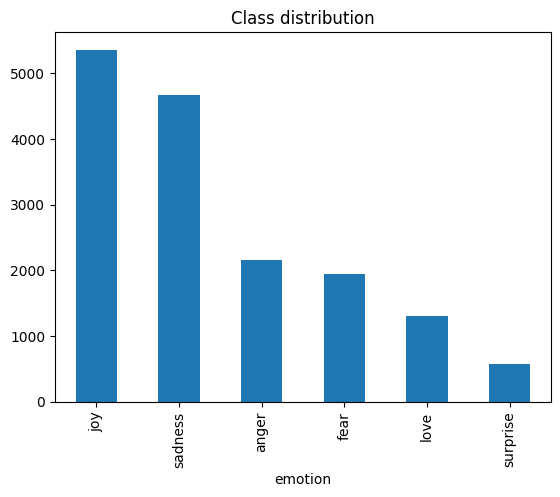

In [4]:
train["emotion"].value_counts().plot(kind="bar", title="Class distribution")

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

test = pd.DataFrame(ds["test"])

vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vec.fit_transform(train["text"])
X_test = vec.transform(test["text"])

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, train["label"])

preds = clf.predict(X_test)
print(classification_report(test["label"], preds, target_names=labels))
print("Macro F1:", f1_score(test["label"], preds, average="macro"))

              precision    recall  f1-score   support

     sadness       0.87      0.91      0.89       581
         joy       0.78      0.97      0.86       695
        love       0.85      0.50      0.63       159
       anger       0.90      0.72      0.80       275
        fear       0.87      0.72      0.79       224
    surprise       0.95      0.27      0.42        66

    accuracy                           0.83      2000
   macro avg       0.87      0.68      0.73      2000
weighted avg       0.84      0.83      0.82      2000

Macro F1: 0.7326758043058068


In [6]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=64)

tokenized = ds.map(tokenize, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [7]:
import numpy as np
from transformers import (AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import f1_score, accuracy_score

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=6
)

def compute_metrics(eval_pred):
    logits, y = eval_pred
    p = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(y, p),
            "macro_f1": f1_score(y, p, average="macro")}

args = TrainingArguments(
    output_dir="distilbert-emotion",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.449112,0.191977,0.928500,0.906088
2,0.134740,0.138963,0.944500,0.921972
3,0.085451,0.137572,0.941500,0.916415


TrainOutput(global_step=1500, training_loss=0.2231006342569987, metrics={'train_runtime': 91.7179, 'train_samples_per_second': 523.344, 'train_steps_per_second': 16.354, 'total_flos': 644648902596864.0, 'train_loss': 0.2231006342569987, 'epoch': 3.0})

In [8]:
out = trainer.predict(tokenized["test"])
preds = np.argmax(out.predictions, axis=-1)
print(classification_report(test["label"], preds, target_names=labels))
print("Macro F1:", f1_score(test["label"], preds, average="macro"))

              precision    recall  f1-score   support

     sadness       0.97      0.97      0.97       581
         joy       0.95      0.96      0.95       695
        love       0.85      0.81      0.83       159
       anger       0.94      0.90      0.92       275
        fear       0.85      0.95      0.90       224
    surprise       0.86      0.65      0.74        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000

Macro F1: 0.884551134188159


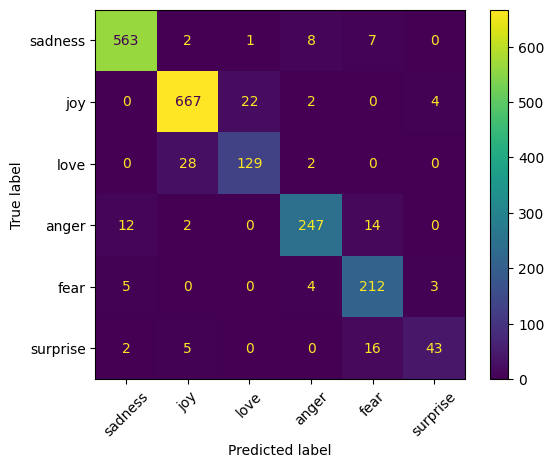

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test["label"], preds, display_labels=labels, xticks_rotation=45
)

In [10]:
test["pred"] = preds
wrong = test[test["label"] != test["pred"]].copy()
wrong["true_emotion"] = wrong["label"].map(lambda i: labels[i])
wrong["pred_emotion"] = wrong["pred"].map(lambda i: labels[i])

print(len(wrong), "misclassified out of", len(test))
print(wrong[["text", "true_emotion", "pred_emotion"]].sample(15, random_state=42).to_string())

139 misclassified out of 2000
                                                                                                                                                                                                                                                                                  text true_emotion pred_emotion
1935                                                                                                                                                                                                           ive started feeling like almost nothing is worth getting agitated about         fear        anger
960                                                                                                                            i feel passionate about knitting and seeing really good films and the surprisingly awesome tv programs that are on now i cant believe i just wrote that         love          joy
501                                                    

## Error Analysis

DistilBERT reached a macro F1 of 0.885, up from 0.733 for the TF-IDF baseline.
Accuracy rose from 0.83 to 0.93.

**Where it fails:** The largest confusion is between joy and love: 28 love
tweets were predicted as joy and 22 joy tweets as love. Surprise is the
weakest class, with 16 of 66 surprise tweets predicted as fear. Anger is
occasionally mistaken for fear (14) and sadness (12).

**Why:** These are pairs of emotions that are close in meaning and often
appear in similar wording, so a human reader could plausibly choose either
label. The dataset labels were assigned automatically from hashtags, which
adds noise. Surprise and love also have far fewer training examples than
joy and sadness, which makes them harder to learn.

**Possible improvements:** class-weighted loss, oversampling rare emotions,
or a larger model such as BERT-base or RoBERTa.

In [11]:
trainer.save_model("distilbert-emotion-final")
tokenizer.save_pretrained("distilbert-emotion-final")

!zip -r distilbert-emotion-final.zip distilbert-emotion-final

from google.colab import files
files.download("distilbert-emotion-final.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: distilbert-emotion-final/ (stored 0%)
  adding: distilbert-emotion-final/training_args.bin (deflated 54%)
  adding: distilbert-emotion-final/model.safetensors (deflated 8%)
  adding: distilbert-emotion-final/config.json (deflated 54%)
  adding: distilbert-emotion-final/tokenizer_config.json (deflated 43%)
  adding: distilbert-emotion-final/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>